In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [115]:
df = pd.read_csv('/content/diabetic_data.csv')

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [116]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-

In [117]:
df = df.replace('?', np.nan)

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                    

In [118]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())


Duplicate Rows:
0
Duplicates before: 0
Duplicates after: 0


In [119]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print("\n30-Day Readmission Distribution:")
print(df['readmitted_30'].value_counts())


30-Day Readmission Distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [120]:
features = [
    'age',
    'gender',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'A1Cresult',
    'insulin',
    'diabetesMed'
]

X = df[features]
y = df['readmitted_30']

In [121]:
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='object').columns

for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values after handling:")
print(X.isnull().sum())

Missing values after handling:
age                   0
gender                0
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
A1Cresult             0
insulin               0
diabetesMed           0
dtype: int64


/tmp/ipykernel_1169/2492779257.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
/tmp/ipykernel_1169/2492779257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


In [122]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

X.head()

Features after encoding: (101766, 25)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_[10-20),age_[20-30),...,age_[80-90),age_[90-100),gender_Male,gender_Unknown/Invalid,A1Cresult_>8,A1Cresult_Norm,insulin_No,insulin_Steady,insulin_Up,diabetesMed_Yes
0,1,41,0,1,0,0,0,1,False,False,...,False,False,False,False,True,False,True,False,False,False
1,3,59,0,18,0,0,0,9,True,False,...,False,False,False,False,True,False,False,False,True,True
2,2,11,5,13,2,0,1,6,False,True,...,False,False,False,False,True,False,True,False,False,True
3,2,44,1,16,0,0,0,7,False,False,...,False,False,True,False,True,False,False,False,True,True
4,1,51,0,8,0,0,0,5,False,False,...,False,False,True,False,True,False,False,True,False,True


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [124]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
model = LogisticRegression(
    penalty='l2',
    C=0.2,
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.2, class_weight='balanced', max_iter=1000)

In [126]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:10])

[0.56174826 0.4370227  0.49843602 0.4796137  0.52735686 0.34945312
 0.38980883 0.39186326 0.74741316 0.55275418]


In [127]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6430502356264023


In [129]:
y_pred = (y_prob >= 0.5).astype(int)

print(y_pred[:20])

[1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0]


In [130]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12642  5441]
 [ 1139  1132]]


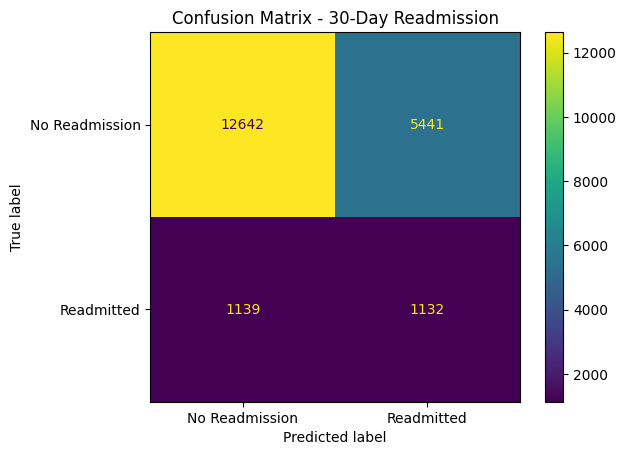

In [131]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Readmission', 'Readmitted']
).plot()

plt.title('Confusion Matrix - 30-Day Readmission')
plt.show()

In [132]:
TN, FP, FN, TP = cm.ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 12642
False Positives: 5441
False Negatives: 1139
True Positives : 1132
